# Keras Text Neural Network

This notebook trains the first neural network in the project.

The model uses only `claim_text`. It does not use chart images yet.

## Architecture

The model contains:

- `TextVectorization`;
- `Embedding`;
- `GlobalAveragePooling1D`;
- `Dropout`;
- a hidden `Dense` layer;
- a three-class softmax output.

The vectorizer is adapted only with training text.

In [1]:
from pathlib import Path
import sys

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.text_neural_network import (
    LABEL_ORDER,
    build_text_neural_network,
    create_text_vectorizer,
    decode_predictions,
    encode_labels,
)

keras.utils.set_random_seed(42)

In [2]:
processed_directory = (
    project_root
    / "data"
    / "processed"
)

train_data = pd.read_csv(
    processed_directory
    / "train_chart_claim_dataset.csv"
)

validation_data = pd.read_csv(
    processed_directory
    / "validation_chart_claim_dataset.csv"
)

print("Training rows:", len(train_data))
print(
    "Validation rows:",
    len(validation_data),
)

train_data[
    ["claim_text", "label"]
].head()

Training rows: 252
Validation rows: 54


,claim_text,label
0,The EU unemployment rate was higher in 2020 th...,supported
1,The EU unemployment rate was lower in 2020 tha...,refuted
2,The EU unemployment rate was higher in 2023 th...,not_enough_information
3,The EU unemployment rate was lower in 2021 tha...,supported
4,The EU unemployment rate was higher in 2021 th...,refuted


In [3]:
train_text = (
    train_data["claim_text"]
    .astype(str)
    .to_numpy()
)

validation_text = (
    validation_data["claim_text"]
    .astype(str)
    .to_numpy()
)

train_labels = encode_labels(
    train_data["label"]
)

validation_labels = encode_labels(
    validation_data["label"]
)

print(
    "Encoded classes:",
    dict(enumerate(LABEL_ORDER)),
)

Encoded classes: {0: 'supported', 1: 'refuted', 2: 'not_enough_information'}


## Text vectorization

The vocabulary is learned only from the training claims.

In [4]:
vectorizer = create_text_vectorizer(
    training_text=train_text,
    max_tokens=1000,
    sequence_length=24,
)

vocabulary = (
    vectorizer.get_vocabulary()
)

print("Vocabulary size:", len(vocabulary))
print("First tokens:", vocabulary[:20])

Vocabulary size: 19
First tokens: ['', '[UNK]', np.str_('in'), np.str_('was'), np.str_('unemployment'), np.str_('the'), np.str_('than'), np.str_('rate'), np.str_('eu'), np.str_('higher'), np.str_('2022'), np.str_('2023'), np.str_('2021'), np.str_('lower'), np.str_('2024'), np.str_('2020'), np.str_('2025'), np.str_('2026'), np.str_('2019')]


## Build the neural network

In [5]:
text_model = (
    build_text_neural_network(
        vectorizer=vectorizer,
        embedding_dimension=32,
        hidden_units=32,
        dropout_rate=0.30,
        learning_rate=0.001,
    )
)

text_model.summary()

Model: "text_neural_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃       Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ claim_text (InputLayer)  │ (None)               │             0 │ -                     │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ text_vectorization       │ (None, 24)           │             0 │ claim_text[0][0]      │
│ (TextVectorization)      │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ token_embedding          │ (None, 24, 32)       │           608 │ text_vectorization[0… │
│ (Embedding)              │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ not_equal (NotEqual)     │ (None, 24)           │             0 │ text_vectorization[0… │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ average_pooling          │ (None, 32)           │             0 │ token_embedding[0][0… │
│ (GlobalAveragePooling1D) │                      │               │ not_equal[0][0]       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ first_dropout (Dropout)  │ (None, 32)           │             0 │ average_pooling[0][0] │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ hidden_dense (Dense)     │ (None, 32)           │         1,056 │ first_dropout[0][0]   │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ second_dropout (Dropout) │ (None, 32)           │             0 │ hidden_dense[0][0]    │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ class_probabilities      │ (None, 3)            │            99 │ second_dropout[0][0]  │
│ (Dense)                  │                      │               │                       │
└──────────────────────────┴──────────────────────┴───────────────┴───────────────────────┘

 Total params: 1,763 (6.89 KB)

 Trainable params: 1,763 (6.89 KB)

 Non-trainable params: 0 (0.00 B)

## Training

Early stopping monitors validation loss and restores the best model
weights.

In [6]:
early_stopping = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    )
)

history = text_model.fit(
    train_text,
    train_labels,
    validation_data=(
        validation_text,
        validation_labels,
    ),
    epochs=40,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0,
)

print(
    "Epochs completed:",
    len(history.history["loss"]),
)

Epochs completed: 40


In [7]:
history_data = pd.DataFrame(
    history.history
)

history_data.index = (
    history_data.index + 1
)

history_data.index.name = "epoch"

history_data.tail()

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
36,0.801587,0.532573,0.833333,0.538427
37,0.813492,0.520504,0.833333,0.526915
38,0.801587,0.528088,0.833333,0.512262
39,0.809524,0.510588,0.833333,0.513411
40,0.805556,0.509081,0.833333,0.505480


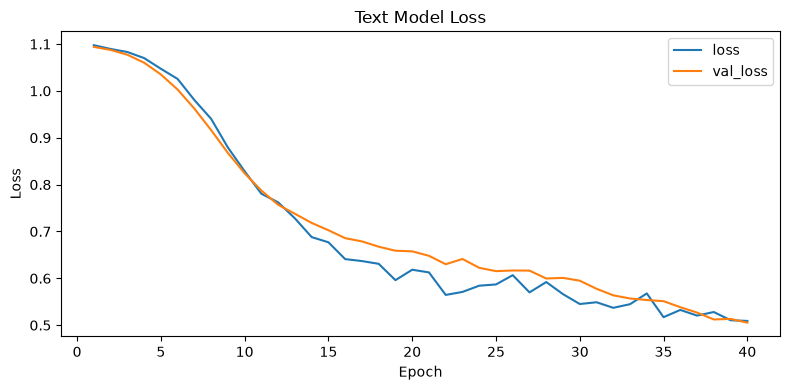

In [8]:
history_data[
    ["loss", "val_loss"]
].plot(
    figsize=(8, 4),
)

plt.title("Text Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

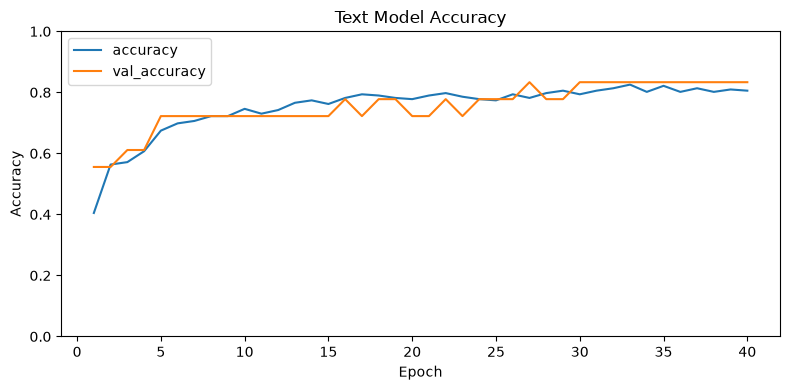

In [9]:
history_data[
    ["accuracy", "val_accuracy"]
].plot(
    figsize=(8, 4),
)

plt.title("Text Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Validation evaluation

In [10]:
validation_probabilities = (
    text_model.predict(
        validation_text,
        verbose=0,
    )
)

validation_indices = np.argmax(
    validation_probabilities,
    axis=1,
)

validation_predictions = (
    decode_predictions(
        validation_indices
    )
)

validation_accuracy = (
    accuracy_score(
        validation_data["label"],
        validation_predictions,
    )
)

validation_macro_f1 = f1_score(
    validation_data["label"],
    validation_predictions,
    average="macro",
    zero_division=0,
)

text_neural_metrics = pd.DataFrame(
    [
        {
            "model": (
                "Keras text neural network"
            ),
            "accuracy": (
                validation_accuracy
            ),
            "macro_f1": (
                validation_macro_f1
            ),
            "evaluation_split": (
                "validation"
            ),
        }
    ]
)

text_neural_metrics

,model,accuracy,macro_f1,evaluation_split
0,Keras text neural network,0.833333,0.827894,validation


In [11]:
validation_report = pd.DataFrame(
    classification_report(
        validation_data["label"],
        validation_predictions,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
).transpose()

validation_report

,precision,recall,f1-score,support
supported,0.800000,0.666667,0.727273,18.000000
refuted,0.833333,0.833333,0.833333,18.000000
not_enough_information,0.857143,1.000000,0.923077,18.000000
accuracy,0.833333,0.833333,0.833333,0.833333
macro avg,0.830159,0.833333,0.827894,54.000000
weighted avg,0.830159,0.833333,0.827894,54.000000


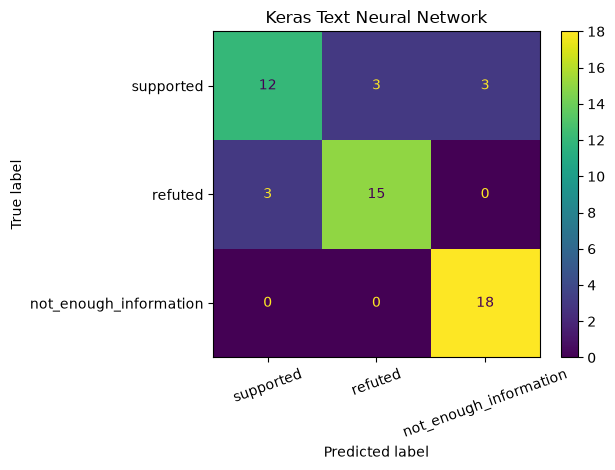

In [12]:
validation_matrix = (
    confusion_matrix(
        validation_data["label"],
        validation_predictions,
        labels=LABEL_ORDER,
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=(
        validation_matrix
    ),
    display_labels=LABEL_ORDER,
).plot(
    xticks_rotation=20,
)

plt.title(
    "Keras Text Neural Network"
)
plt.tight_layout()
plt.show()

## Comparison with the simple baselines

In [13]:
baseline_path = (
    project_root
    / "reports"
    / "baseline_validation_metrics.csv"
)

baseline_results = pd.read_csv(
    baseline_path
)

model_comparison = pd.concat(
    [
        baseline_results,
        text_neural_metrics,
    ],
    ignore_index=True,
)

model_comparison

,model,accuracy,macro_f1,evaluation_split
0,Majority baseline,0.333333,0.166667,validation
1,TF-IDF + Logistic Regression,0.777778,0.772339,validation
2,Keras text neural network,0.833333,0.827894,validation


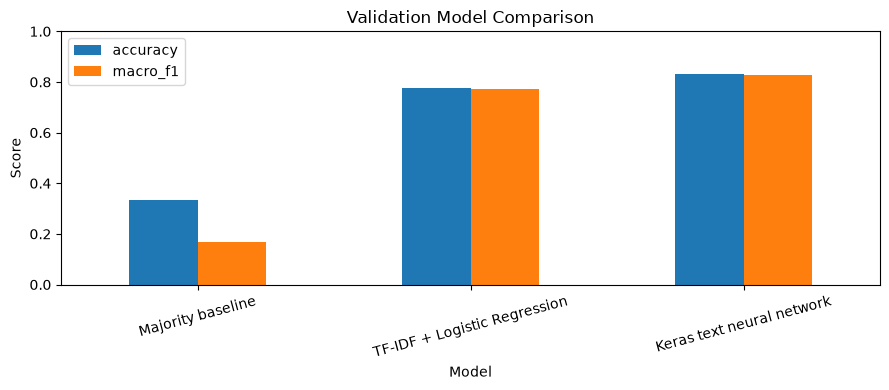

In [14]:
model_comparison.set_index(
    "model"
)[
    ["accuracy", "macro_f1"]
].plot(
    kind="bar",
    figsize=(9, 4),
)

plt.title(
    "Validation Model Comparison"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Save the results

The trained model file is stored locally under `models`. Model files are
ignored by Git because they can be generated again.

In [15]:
reports_directory = (
    project_root / "reports"
)

models_directory = (
    project_root / "models"
)

reports_directory.mkdir(
    parents=True,
    exist_ok=True,
)

models_directory.mkdir(
    parents=True,
    exist_ok=True,
)

history_data.to_csv(
    reports_directory
    / "text_neural_network_history.csv"
)

text_neural_metrics.to_csv(
    reports_directory
    / (
        "text_neural_network_"
        "validation_metrics.csv"
    ),
    index=False,
)

validation_report.to_csv(
    reports_directory
    / (
        "text_neural_network_"
        "validation_report.csv"
    )
)

pd.DataFrame(
    validation_matrix,
    index=[
        f"actual_{label}"
        for label in LABEL_ORDER
    ],
    columns=[
        f"predicted_{label}"
        for label in LABEL_ORDER
    ],
).to_csv(
    reports_directory
    / (
        "text_neural_network_"
        "validation_confusion_matrix.csv"
    )
)

model_comparison.to_csv(
    reports_directory
    / "model_validation_comparison.csv",
    index=False,
)

text_model.save(
    models_directory
    / "text_neural_network.keras"
)

print("Text model and reports saved.")

Text model and reports saved.


## Result

The final validation metrics are produced by the training run above.

The model must be compared with the TF-IDF baseline. A better or similar
text score still does not prove chart understanding because this model
has not received image input.

The test split remains untouched.